 
    # Proyecto Final Data Science

## Condiciones oceanograficas y dos especies marinas en CalCOFI

### Objetivo del proyecto

Queremos estudiar si las condiciones del oceano, la localizacion y el tiempo ayudan a diferenciar dos especies importantes dentro de los datos de CalCOFI:

- `Engraulis mordax`
- `Sardinops sagax`

Primero trabajamos con el conjunto completo de datos biologicos y oceanograficos para preparar una base solida y entender el muestreo.

Despues del analisis general centramos el caso de estudio en estas dos especies.

### Objetivo de Machine Learning

Vamos a plantear un problema de clasificacion binaria.

A partir de variables como temperatura, salinidad, oxigeno, nutrientes, fecha y localizacion queremos predecir si un registro corresponde a `Engraulis mordax` o a `Sardinops sagax`.

El modelo no intentara calcular la cantidad total de peces que hay en el oceano. Trabajara con los registros disponibles en el dataset.


## 1. Cargamos los datos oceanograficos

Empezamos con dos archivos:

- `cast.csv`: informacion de cada muestreo oceanografico
- `bottle.csv`: mediciones del agua tomadas dentro de cada muestreo

La columna que relaciona las dos tablas es `Cst_Cnt`.


In [1]:
import pandas as pd
import sqlite3


In [2]:
# Cargamos los datos oceanograficos

bottle = pd.read_csv("../../data/raw/bottle.csv")
cast = pd.read_csv("../../data/raw/cast.csv")


/tmp/ipykernel_1409/4050277854.py:3: DtypeWarning: Columns (0: IncTim, 1: DIC Quality Comment) have mixed types. Specify dtype option on import or set low_memory=False.
  bottle = pd.read_csv("../../data/raw/bottle.csv")
/tmp/ipykernel_1409/4050277854.py:4: DtypeWarning: Columns (0: Data_Or, 1: Cruz_Num, 2: Inc_Str, 3: Inc_End, 4: PST_LAN, 5: Civil_T) have mixed types. Specify dtype option on import or set low_memory=False.
  cast = pd.read_csv("../../data/raw/cast.csv")


In [3]:
# Vemos el tamaño de los dos datasets

print("Bottle:", bottle.shape)
print("Cast:", cast.shape)


Bottle: (864863, 74)
Cast: (34404, 61)


## 2. Entendemos la relacion entre `cast` y `bottle`

`cast` representa un muestreo oceanografico.

Dentro de un mismo `cast` puede haber varias muestras `bottle`, normalmente tomadas a distintas profundidades.

Por eso un mismo `Cst_Cnt` puede aparecer muchas veces en `bottle`.


In [4]:
# Vemos cuantas mediciones bottle tiene cada muestreo

bottle["Cst_Cnt"].value_counts().head(10)


Cst_Cnt
14467    80
14083    79
13957    78
14082    78
12467    76
13566    76
15477    76
11715    75
13569    75
13776    75
Name: count, dtype: int64

## 3. Revisamos todas las variables

Antes de elegir con cuales trabajar revisamos:

- tipo de dato
- datos disponibles
- nulos
- porcentaje de nulos

Primero vemos la calidad de las variables y despues hacemos la seleccion.


In [5]:
# Creamos un resumen de todas las variables

resumen_bottle = pd.DataFrame({
    "tabla": "bottle",
    "variable": bottle.columns,
    "datos_disponibles": bottle.notnull().sum().values,
    "nulos": bottle.isnull().sum().values,
    "porcentaje_nulos": (bottle.isnull().mean() * 100).round(2).values
})

resumen_cast = pd.DataFrame({
    "tabla": "cast",
    "variable": cast.columns,
    "datos_disponibles": cast.notnull().sum().values,
    "nulos": cast.isnull().sum().values,
    "porcentaje_nulos": (cast.isnull().mean() * 100).round(2).values
})

resumen_variables = pd.concat(
    [resumen_bottle, resumen_cast],
    ignore_index=True
)

resumen_variables.shape

(135, 5)

## 4. Primera criba por nulos

Como primera criba dejamos fuera de momento las variables con mas del 80% de nulos.

Este 80% es una decision practica del proyecto, no una regla general.

Despues de esta criba miramos `cast` y `bottle` por separado antes de elegir las variables que vamos a usar.


In [6]:
# Mostramos todas las variables antes de aplicar ningún filtro

variables_completas = resumen_variables[
    ["tabla", "variable", "porcentaje_nulos"]
].reset_index(drop=True)

mitad = (len(variables_completas) + 1) // 2

izquierda = variables_completas.iloc[:mitad].reset_index(drop=True)
derecha = variables_completas.iloc[mitad:].reset_index(drop=True)

tabla_completa = pd.concat(
    [izquierda, derecha],
    axis=1
)

tabla_completa.columns = [
    "tabla_1",
    "variable_1",
    "porcentaje_nulos_1",
    "tabla_2",
    "variable_2",
    "porcentaje_nulos_2"
]

tabla_completa

,tabla_1,variable_1,porcentaje_nulos_1,tabla_2,variable_2,porcentaje_nulos_2
0,bottle,Cst_Cnt,0.00,bottle,DIC2,99.97
1,bottle,Btl_Cnt,0.00,bottle,TA1,99.76
2,bottle,Sta_ID,0.00,bottle,TA2,99.97
3,bottle,Depth_ID,0.00,bottle,pH2,100.00
4,bottle,Depthm,0.00,bottle,pH1,99.99
...,...,...,...,...,...,...
63,bottle,R_CHLA,73.95,cast,Wea,22.08
64,bottle,R_PHAEO,73.95,cast,Cloud_Typ,71.17
65,bottle,R_PRES,0.00,cast,Cloud_Amt,65.46
66,bottle,R_SAMP,85.89,cast,Visibility,72.37


In [7]:
# Filtramos las variables con 80 % o menos de nulos

variables_simple = resumen_variables[
    resumen_variables["porcentaje_nulos"] <= 80
][
    ["tabla", "variable", "porcentaje_nulos"]
].reset_index(drop=True)

len(variables_simple)


102

In [8]:
# Dejamos las variables con un 80% o menos de nulos

variables_filtradas = resumen_variables[
    resumen_variables["porcentaje_nulos"] <= 80
]

variables_filtradas.shape


(102, 5)

## 5. Revisamos y elegimos las variables de `cast`

Primero miramos las variables de `cast` que han pasado la criba del 80% de nulos.


In [9]:
# Variables de cast que han pasado la criba

variables_cast = variables_filtradas[
    variables_filtradas["tabla"] == "cast"
]

variables_cast.sort_values(
    "porcentaje_nulos",
    ascending=False
)


,tabla,variable,datos_disponibles,nulos,porcentaje_nulos
134,cast,Visibility,9507,24897,72.37
132,cast,Cloud_Typ,9920,24484,71.17
110,cast,Order_Occ,9954,24450,71.07
125,cast,Wave_Prd,11634,22770,66.18
133,cast,Cloud_Amt,11882,22522,65.46
124,cast,Wave_Ht,12098,22306,64.84
116,cast,IntChl,12203,22201,64.53
123,cast,Wave_Dir,12558,21846,63.50
114,cast,Data_Or,18275,16129,46.88
130,cast,Wet_T,18989,15415,44.81


### Variables de `cast` que vamos a usar

| Variable | Que significa |
|---|---|
| `Cst_Cnt` | Identificador del muestreo |
| `Cruise_ID` | Campaña oceanografica |
| `Sta_ID` | Estacion de muestreo |
| `Date` | Fecha |
| `Year` | Año |
| `Month` | Mes |
| `Lat_Dec` | Latitud |
| `Lon_Dec` | Longitud |
| `Distance` | Distancia a la costa |
| `Bottom_D` | Profundidad del fondo |
| `IntChl` | Clorofila integrada |
| `Wind_Spd` | Velocidad del viento |
| `Wave_Ht` | Altura de las olas |
| `Barometer` | Presion atmosferica |
| `Dry_T` | Temperatura del aire |
| `Wet_T` | Temperatura humeda |

Nos quedamos con ellas porque pueden ayudarnos a describir donde y cuando se hizo cada muestreo y las condiciones ambientales del lugar.

In [10]:
# Seleccionamos las variables de cast

columnas_cast = [
    "Cst_Cnt",
    "Cruise_ID",
    "Sta_ID",
    "Date",
    "Year",
    "Month",
    "Lat_Dec",
    "Lon_Dec",
    "Distance",
    "Bottom_D",
    "IntChl",
    "Wind_Spd",
    "Wave_Ht",
    "Barometer",
    "Dry_T",
    "Wet_T"
]

cast_seleccionado = cast[columnas_cast].copy()

cast_seleccionado.shape


(34404, 16)

## 6. Revisamos y elegimos las variables de `bottle`

Ahora hacemos lo mismo con `bottle`: miramos las variables que han pasado la criba y despues elegimos las que describen mejor las condiciones del agua.


In [11]:
# Variables de bottle que han pasado la criba

variables_bottle = variables_filtradas[
    variables_filtradas["tabla"] == "bottle"
]

variables_bottle.sort_values(
    "porcentaje_nulos",
    ascending=False
)


,tabla,variable,datos_disponibles,nulos,porcentaje_nulos
18,bottle,O_qual,184676,680187,78.65
20,bottle,O2Satq,217797,647066,74.82
21,bottle,ChlorA,225272,639591,73.95
64,bottle,R_PHAEO,225275,639588,73.95
63,bottle,R_CHLA,225276,639587,73.95
23,bottle,Phaeop,225271,639592,73.95
31,bottle,NO3uM,337403,527460,60.99
60,bottle,R_NO3,337411,527452,60.99
61,bottle,R_NO2,337584,527279,60.97
29,bottle,NO2uM,337576,527287,60.97


### Variables de `bottle` que vamos a usar

| Variable | Que significa |
|---|---|
| `Cst_Cnt` | Identificador del muestreo |
| `Btl_Cnt` | Identificador de la muestra |
| `Depthm` | Profundidad de la muestra |
| `T_degC` | Temperatura del agua |
| `Salnty` | Salinidad |
| `STheta` | Densidad del agua |
| `O2ml_L` | Oxigeno disuelto |
| `O2Sat` | Saturacion de oxigeno |
| `Oxy_µmol/Kg` | Oxigeno medido en otra unidad |
| `ChlorA` | Clorofila |
| `Phaeop` | Pigmentos relacionados con la clorofila |
| `PO4uM` | Fosfato |
| `SiO3uM` | Silicato |
| `NO2uM` | Nitrito |
| `NO3uM` | Nitrato |

Las mantenemos como variables candidatas porque describen distintas condiciones del agua. Mas adelante el EDA nos ayudara a decidir cuales aportan realmente informacion.

In [12]:
# Seleccionamos las variables de bottle

columnas_bottle = [
    "Cst_Cnt",
    "Btl_Cnt",
    "Depthm",
    "T_degC",
    "Salnty",
    "STheta",
    "O2ml_L",
    "O2Sat",
    "Oxy_µmol/Kg",
    "ChlorA",
    "Phaeop",
    "PO4uM",
    "SiO3uM",
    "NO2uM",
    "NO3uM"
]

bottle_seleccionado = bottle[columnas_bottle].copy()

bottle_seleccionado.shape

(864863, 15)

## 7. Trabajamos los datos seleccionados con SQL

Ya hemos revisado las variables y hemos elegido las que vamos a usar en el proyecto.

Ahora guardamos estas dos tablas seleccionadas en SQLite para trabajar una parte con SQL y comprobar la relacion entre `cast` y `bottle` mediante `Cst_Cnt`.

No estamos usando una muestra: seguimos manteniendo todas las filas, pero solo con las variables que ya hemos decidido usar.

Despues de esta parte seguimos trabajando con Pandas.


In [13]:
# Conectamos con la base de datos

conn = sqlite3.connect("../../data/calcofi.db")


In [14]:
# Guardamos en SQL las tablas ya seleccionadas

bottle_seleccionado.to_sql(
    "bottle_seleccionado",
    conn,
    if_exists="replace",
    index=False
)

cast_seleccionado.to_sql(
    "cast_seleccionado",
    conn,
    if_exists="replace",
    index=False
)


34404

In [15]:
# Guardamos con INSERT un resumen de las tablas

conn.execute("""
CREATE TABLE IF NOT EXISTS resumen_sql (
    tabla TEXT,
    filas INTEGER
)
""")

# Evitamos repetir datos si volvemos a ejecutar la celda
conn.execute("DELETE FROM resumen_sql")

conn.execute("""
INSERT INTO resumen_sql (tabla, filas)
SELECT 'bottle_seleccionado', COUNT(*)
FROM bottle_seleccionado
""")

conn.execute("""
INSERT INTO resumen_sql (tabla, filas)
SELECT 'cast_seleccionado', COUNT(*)
FROM cast_seleccionado
""")

conn.commit()

pd.read_sql_query("""
SELECT *
FROM resumen_sql;
""", conn)

,tabla,filas
0,bottle_seleccionado,864863
1,cast_seleccionado,34404


In [16]:
# Comprobamos la relacion entre cast y bottle con un JOIN

pd.read_sql_query(
    '''
    SELECT *
    FROM bottle_seleccionado AS b
    INNER JOIN cast_seleccionado AS c
    ON b.Cst_Cnt = c.Cst_Cnt
    LIMIT 5
    ''',
    conn
)


,Cst_Cnt,Btl_Cnt,Depthm,T_degC,Salnty,STheta,O2ml_L,O2Sat,Oxy_µmol/Kg,ChlorA,...,Lat_Dec,Lon_Dec,Distance,Bottom_D,IntChl,Wind_Spd,Wave_Ht,Barometer,Dry_T,Wet_T
0,1,1,0,10.50,33.440,25.649,None,None,None,None,...,38.833333,-124.083333,None,None,None,18.0,None,None,None,None
1,1,2,8,10.46,33.440,25.656,None,None,None,None,...,38.833333,-124.083333,None,None,None,18.0,None,None,None,None
2,1,3,10,10.46,33.437,25.654,None,None,None,None,...,38.833333,-124.083333,None,None,None,18.0,None,None,None,None
3,1,4,19,10.45,33.420,25.643,None,None,None,None,...,38.833333,-124.083333,None,None,None,18.0,None,None,None,None
4,1,5,20,10.45,33.421,25.643,None,None,None,None,...,38.833333,-124.083333,None,None,None,18.0,None,None,None,None


## 8. Creamos el dataset oceanografico con Pandas

Despues de comprobar la relacion con SQL, seguimos el proyecto con Pandas.

Unimos `bottle_seleccionado` y `cast_seleccionado` mediante `Cst_Cnt`.


In [17]:
# Unimos cast y bottle con Pandas

datos_trabajo = pd.merge(
    bottle_seleccionado,
    cast_seleccionado,
    on="Cst_Cnt",
    how="inner"
)

datos_trabajo.shape


(864863, 30)

In [18]:
# Revisamos la estructura del dataset oceanografico

datos_trabajo.info()


<class 'pandas.DataFrame'>
RangeIndex: 864863 entries, 0 to 864862
Data columns (total 30 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Cst_Cnt      864863 non-null  int64  
 1   Btl_Cnt      864863 non-null  int64  
 2   Depthm       864863 non-null  int64  
 3   T_degC       853900 non-null  float64
 4   Salnty       817509 non-null  float64
 5   STheta       812174 non-null  float64
 6   O2ml_L       696201 non-null  float64
 7   O2Sat        661274 non-null  float64
 8   Oxy_µmol/Kg  661268 non-null  float64
 9   ChlorA       225272 non-null  float64
 10  Phaeop       225271 non-null  float64
 11  PO4uM        413317 non-null  float64
 12  SiO3uM       354091 non-null  float64
 13  NO2uM        337576 non-null  float64
 14  NO3uM        337403 non-null  float64
 15  Cruise_ID    864863 non-null  str    
 16  Sta_ID       864863 non-null  str    
 17  Date         864863 non-null  str    
 18  Year         864863 non-null  int64

In [19]:
# Revisamos los nulos del dataset oceanografico

datos_trabajo.isnull().sum()


Cst_Cnt             0
Btl_Cnt             0
Depthm              0
T_degC          10963
Salnty          47354
STheta          52689
O2ml_L         168662
O2Sat          203589
Oxy_µmol/Kg    203595
ChlorA         639591
Phaeop         639592
PO4uM          451546
SiO3uM         510772
NO2uM          527287
NO3uM          527460
Cruise_ID           0
Sta_ID              0
Date                0
Year                0
Month               0
Lat_Dec             0
Lon_Dec             0
Distance       355072
Bottom_D        59227
IntChl         533636
Wind_Spd        28164
Wave_Ht        570557
Barometer      397060
Dry_T          396695
Wet_T          398061
dtype: int64

## 9. Cargamos los datos biologicos

Ahora necesitamos saber que especies aparecen, cuando aparecen y donde se hizo cada registro.

Para eso usamos `occurrence.txt`.

No nos centramos en una especie concreta. Queremos trabajar con distintas especies marinas.


In [20]:
# Cargamos occurrence

biologico = pd.read_csv(
    "../../data/raw/biologico/calcofi_ichthyo/occurrence.txt",
    sep="\t"
)

biologico.shape


(463655, 13)

In [21]:
# Vemos las columnas disponibles

biologico.columns.tolist()


['id',
 'modified',
 'basisOfRecord',
 'occurrenceID',
 'organismQuantity',
 'organismQuantityType',
 'lifeStage',
 'occurrenceStatus',
 'preparations',
 'eventID',
 'scientificNameID',
 'scientificName',
 'kingdom']

## 10. Revisamos las especies

Antes de unir los datos biologicos con los oceanograficos comprobamos que nombres aparecen en `scientificName`.

Vemos que algunos registros no representan una especie concreta, sino grupos mas generales como `Teleostei`.

Primero limpiamos esos nombres para construir correctamente el dataset general.

Mas adelante, una vez unido y revisado todo, centraremos el caso de estudio en `Engraulis mordax` y `Sardinops sagax`.


In [22]:
# Numero de especies distintas

biologico["scientificName"].nunique()


899

In [23]:
# Especies con mas registros

biologico["scientificName"].value_counts().head(20)


scientificName
Teleostei                       72797
Engraulis mordax                42044
Sebastes                        18187
Vinciguerria lucetia            14829
Triphoturus mexicanus           14572
Merluccius productus            14281
Sardinops sagax                 13326
Protomyctophum crockeri         12893
Stenobrachius leucopsarus       12726
Leuroglossus stilbius           12454
Trachurus symmetricus           10632
Lipolagus ochotensis             8554
Lampanyctus                      7777
Bathylagoides wesethi            7588
Cololabis saira                  7377
Diogenichthys laternatus         6058
Citharichthys stigmaeus          5947
Tarletonbeania crenularis        5584
Cyclothone signata               5526
Symbolophorus californiensis     5465
Name: count, dtype: int64

### Revisamos los nombres biologicos

Al mirar `scientificName` vemos que no todos los registros son especies concretas. Algunos son grupos mas generales, como `Teleostei`.

Por eso hacemos una pequeña criba antes de seguir, para quedarnos con nombres que representen mejor especies concretas.



In [24]:
# Hacemos una primera criba para quedarnos con nombres de especies

biologico_especies = biologico[
    biologico["scientificName"].str.contains(" ", na=False)
].copy()

biologico_especies = biologico_especies[
    ~biologico_especies["scientificName"].str.contains(
        r"\bsp\.|\bspp\.|unidentified",
        case=False,
        regex=True,
        na=False
    )
]

biologico_especies.shape

(314149, 13)

In [25]:
# Comprobamos cuantos nombres distintos quedan

biologico_especies["scientificName"].nunique()

548

In [26]:
# Revisamos los nombres con mas registros despues de la criba

biologico_especies["scientificName"].value_counts().head(20)

scientificName
Engraulis mordax                42044
Vinciguerria lucetia            14829
Triphoturus mexicanus           14572
Merluccius productus            14281
Sardinops sagax                 13326
Protomyctophum crockeri         12893
Stenobrachius leucopsarus       12726
Leuroglossus stilbius           12454
Trachurus symmetricus           10632
Lipolagus ochotensis             8554
Bathylagoides wesethi            7588
Cololabis saira                  7377
Diogenichthys laternatus         6058
Citharichthys stigmaeus          5947
Tarletonbeania crenularis        5584
Cyclothone signata               5526
Symbolophorus californiensis     5465
Diogenichthys atlanticus         5131
Ceratoscopelus townsendi         5061
Citharichthys sordidus           3693
Name: count, dtype: int64

## 11. Cargamos los eventos biologicos

`occurrence` nos dice que especie aparece, pero necesitamos saber cuando y donde se hizo el muestreo.

Para eso usamos `event.txt`.


In [27]:
# Cargamos event

eventos = pd.read_csv(
    "../../data/raw/biologico/calcofi_ichthyo/event.txt",
    sep="\t"
)

eventos.shape


/tmp/ipykernel_1409/3325951029.py:3: DtypeWarning: Columns (0: habitat, 1: footprintWKT) have mixed types. Specify dtype option on import or set low_memory=False.
  eventos = pd.read_csv(


(77188, 17)

In [28]:
# Vemos las columnas disponibles

eventos.columns.tolist()


['id',
 'datasetID',
 'eventID',
 'parentEventID',
 'eventType',
 'eventDate',
 'habitat',
 'samplingProtocol',
 'sampleSizeValue',
 'sampleSizeUnit',
 'eventRemarks',
 'locationID',
 'decimalLatitude',
 'decimalLongitude',
 'geodeticDatum',
 'coordinateUncertaintyInMeters',
 'footprintWKT']

## 12. Elegimos las variables de `event`

Nos quedamos con las variables que necesitamos para localizar cada registro biologico.

- `eventID`: identificador del evento y clave para unir con `occurrence`
- `eventDate`: fecha del evento
- `locationID`: identificador de la localizacion
- `decimalLatitude`: latitud
- `decimalLongitude`: longitud

Estas variables nos permiten saber cuando y donde se hizo cada registro biologico y despues relacionarlo con los datos del oceano.


In [29]:
# Seleccionamos las variables de event

columnas_eventos = [
    "eventID",
    "eventDate",
    "locationID",
    "decimalLatitude",
    "decimalLongitude"
]

eventos_seleccionados = eventos[columnas_eventos].copy()

eventos_seleccionados.head()


,eventID,eventDate,locationID,decimalLatitude,decimalLongitude
0,510147,1951-01-19T07:25:00Z/1951-01-29T19:26:00Z,NaN,NaN,NaN
1,5101CR,1951-01-09T18:16:00Z/1951-01-23T03:06:00Z,NaN,NaN,NaN
2,5101HO,1951-01-10T03:40:00Z/1951-01-24T10:06:00Z,NaN,NaN,NaN
3,5102BD,1951-02-09T07:40:00Z/1951-02-25T08:55:00Z,NaN,NaN,NaN
4,5102CR,1951-02-06T20:00:00Z/1951-02-23T13:26:00Z,NaN,NaN,NaN


In [30]:
# Revisamos los nulos

eventos_seleccionados.isnull().sum()


eventID               0
eventDate             0
locationID          676
decimalLatitude     676
decimalLongitude    676
dtype: int64

In [31]:
# Revisamos el porcentaje de nulos

(eventos_seleccionados.isnull().mean() * 100).round(2)


eventID             0.00
eventDate           0.00
locationID          0.88
decimalLatitude     0.88
decimalLongitude    0.88
dtype: float64

## 13. Comprobamos la union biologica

`occurrence` y `event` se relacionan mediante `eventID`.

Antes de unirlas comprobamos que los registros biologicos encuentran su evento y que `eventID` no esta duplicado en `event`.


In [32]:
biologico_especies["eventID"].isin(eventos["eventID"]).value_counts()

eventID
True    314149
Name: count, dtype: int64

## 14. Creamos el dataset biologico

Ahora unimos los registros de especies con la fecha y localizacion de cada evento.


In [33]:
dataset_biologico = pd.merge(
    biologico_especies,
    eventos_seleccionados,
    on="eventID",
    how="inner"
)

## 15. Preparamos la union final

Ya tenemos por un lado los datos del oceano y por otro los datos biologicos.

Como los identificadores de estacion no vienen escritos igual en las dos fuentes, usamos una coincidencia sencilla:

- misma fecha
- misma latitud
- misma longitud

Si coinciden, entendemos que el registro biologico y el oceanografico pertenecen al mismo lugar y momento.


In [34]:
# Creamos copias para preparar la union

oceanografico = datos_trabajo.copy()
biologico_union = dataset_biologico.copy()


In [35]:
# Ponemos las fechas en el mismo formato

oceanografico["Date"] = pd.to_datetime(
    oceanografico["Date"]
).dt.date

biologico_union["eventDate"] = pd.to_datetime(
    biologico_union["eventDate"]
).dt.date


## 16. Unimos los datos biologicos y oceanograficos

Hacemos el `merge` por fecha, latitud y longitud.

Antes de empezar el EDA queremos ver cuanto dataset nos queda realmente.


In [36]:
# Unimos los datos biologicos y oceanograficos

dataset_completo = pd.merge(
    biologico_union,
    oceanografico,
    left_on=["eventDate", "decimalLatitude", "decimalLongitude"],
    right_on=["Date", "Lat_Dec", "Lon_Dec"],
    how="inner"
)

dataset_completo.shape

(2075327, 47)

## 17. Comprobamos como ha quedado el dataset

Despues de hacer todas las uniones primero vamos a comprobar con que dataset nos hemos quedado realmente.

Queremos mirar:

- cuantas filas y columnas tenemos
- cuantas filas tienen completos los datos principales que queremos usar
- si las uniones han repetido registros
- cuantos registros biologicos distintos tenemos

Despues de entender esto ya miraremos las especies y empezaremos el EDA.

In [37]:
# Vemos el tamaño final despues de todas las uniones

dataset_completo.shape

(2075327, 47)

In [38]:
# Comprobamos cuantas filas tienen completos los datos principales

columnas_clave = [
    "scientificName",
    "Lat_Dec",
    "Lon_Dec",
    "Year",
    "Month",
    "Depthm",
    "T_degC",
    "Salnty",
    "O2ml_L"
]

dataset_completo[columnas_clave].dropna().shape

(1525821, 9)

In [39]:
# Dejamos una fila por registro biologico con las variables candidatas

dataset_final = dataset_completo.groupby(
    [
        "occurrenceID",
        "scientificName",
        "Year",
        "Month",
        "Lat_Dec",
        "Lon_Dec"
    ],
    as_index=False
).agg({
    "Sta_ID": "first",
    "Cruise_ID": "first",
    "T_degC": "mean",
    "Salnty": "mean",
    "STheta": "mean",
    "O2ml_L": "mean",
    "O2Sat": "mean",
    "Oxy_µmol/Kg": "mean",
    "ChlorA": "mean",
    "Phaeop": "mean",
    "PO4uM": "mean",
    "SiO3uM": "mean",
    "NO2uM": "mean",
    "NO3uM": "mean",
    "Distance": "mean",
    "Bottom_D": "mean",
    "IntChl": "mean",
    "Wind_Spd": "mean",
    "Wave_Ht": "mean",
    "Barometer": "mean",
    "Dry_T": "mean",
    "Wet_T": "mean"
})

dataset_final.shape

(77448, 28)

In [40]:
# Guardamos el dataset final

dataset_final.to_csv(
    "../../data/processed/dataset_final.csv",
    index=False
)

## Asi queda nuestro dataset general

Despues de unir y preparar todos los datos nos quedamos con `dataset_final`.

Este es nuestro dataset general antes de hacer la criba final de especies.

Tenemos una fila por registro biologico y variables relacionadas con fecha, localizacion y condiciones oceanograficas.

### Variables del dataset

| Variable | Que significa |
|---|---|
| `occurrenceID` | Identificador de cada registro biologico |
| `scientificName` | Nombre cientifico de la especie |
| `Year` | Año |
| `Month` | Mes |
| `Lat_Dec` | Latitud |
| `Lon_Dec` | Longitud |
| `Sta_ID` | Estacion donde se hizo el muestreo |
| `Cruise_ID` | Campaña oceanografica |
| `T_degC` | Temperatura del agua |
| `Salnty` | Salinidad del agua |
| `STheta` | Densidad del agua |
| `O2ml_L` | Oxigeno disuelto |
| `O2Sat` | Saturacion de oxigeno |
| `Oxy_µmol/Kg` | Oxigeno medido en otra unidad |
| `ChlorA` | Clorofila |
| `Phaeop` | Pigmentos relacionados con la clorofila |
| `PO4uM` | Fosfato |
| `SiO3uM` | Silicato |
| `NO2uM` | Nitrito |
| `NO3uM` | Nitrato |
| `Distance` | Distancia a la costa |
| `Bottom_D` | Profundidad del fondo marino |
| `IntChl` | Clorofila integrada |
| `Wind_Spd` | Velocidad del viento |
| `Wave_Ht` | Altura de las olas |
| `Barometer` | Presion atmosferica |
| `Dry_T` | Temperatura del aire |
| `Wet_T` | Temperatura humeda del aire |

A partir de este dataset general haremos el analisis y despues construiremos el dataset especifico para anchoa y sardina.


## Analisis descriptivo

Antes de centrar el estudio en las dos especies revisamos rapidamente como ha quedado el dataset general.


In [41]:
# Cargamos el dataset final preparado

dataset_final = pd.read_csv(
    "../../data/processed/dataset_final.csv"
)

print("Filas:", dataset_final.shape[0])
print("Columnas:", dataset_final.shape[1])

dataset_final.head()


Filas: 77448
Columnas: 28


,occurrenceID,scientificName,Year,Month,Lat_Dec,Lon_Dec,Sta_ID,Cruise_ID,T_degC,Salnty,...,NO2uM,NO3uM,Distance,Bottom_D,IntChl,Wind_Spd,Wave_Ht,Barometer,Dry_T,Wet_T
0,00009931-880e-5189-97d4-ece5d715505a,Argentina sialis,1990,3,34.178333,-119.508333,083.3 042.0,1990-03-04-C-31JD,11.295294,33.751059,...,0.104706,12.958824,-11.44,125.0,396.7,10.0,1.0,1018.5,14.2,13.2
1,00015d2e-8e4d-590e-86f9-64d645156b1b,Vinciguerria lucetia,1958,10,24.091666,-113.658333,140.0 050.0,1958-10-10-C-31BD,15.785517,34.424393,...,NaN,NaN,NaN,3658.0,NaN,5.0,NaN,NaN,NaN,NaN
2,0002550f-15e5-5e3b-abfb-21e734246a86,Scomber japonicus,1954,7,33.783333,-119.516666,085.0 045.0,1954-07-10-C-31CR,11.766471,33.587647,...,NaN,NaN,NaN,1829.0,NaN,5.0,NaN,NaN,NaN,NaN
3,00029a7d-5bd0-5f77-b4f1-792e75a87646,Sardinops sagax,1955,2,28.150000,-116.258333,116.7 050.0,1955-02-11-C-31CR,11.286071,33.866857,...,NaN,NaN,NaN,NaN,NaN,13.0,NaN,NaN,NaN,NaN
4,0002a599-e57b-5a25-9d76-5f6ee8da4abf,Vinciguerria lucetia,1987,3,32.418333,-119.961666,090.0 060.0,1987-03-03-C-31JD,10.743636,33.743697,...,0.021818,17.709091,-129.15,869.0,31.7,18.0,NaN,1017.0,14.9,13.8


In [42]:
# Revisamos la estructura del dataset

dataset_final.info()


<class 'pandas.DataFrame'>
RangeIndex: 77448 entries, 0 to 77447
Data columns (total 28 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   occurrenceID    77448 non-null  str    
 1   scientificName  77448 non-null  str    
 2   Year            77448 non-null  int64  
 3   Month           77448 non-null  int64  
 4   Lat_Dec         77448 non-null  float64
 5   Lon_Dec         77448 non-null  float64
 6   Sta_ID          77448 non-null  str    
 7   Cruise_ID       77448 non-null  str    
 8   T_degC          77394 non-null  float64
 9   Salnty          76594 non-null  float64
 10  STheta          76573 non-null  float64
 11  O2ml_L          59011 non-null  float64
 12  O2Sat           58296 non-null  float64
 13  Oxy_µmol/Kg     58296 non-null  float64
 14  ChlorA          24743 non-null  float64
 15  Phaeop          24743 non-null  float64
 16  PO4uM           32003 non-null  float64
 17  SiO3uM          29824 non-null  float64
 1

In [43]:
# Resumen de las variables numericas

dataset_final.describe()


,Year,Month,Lat_Dec,Lon_Dec,T_degC,Salnty,STheta,O2ml_L,O2Sat,Oxy_µmol/Kg,...,NO2uM,NO3uM,Distance,Bottom_D,IntChl,Wind_Spd,Wave_Ht,Barometer,Dry_T,Wet_T
count,77448.000000,77448.000000,77448.000000,77448.000000,77394.000000,76594.000000,76573.000000,59011.000000,58296.000000,58296.000000,...,26884.000000,27736.000000,43670.000000,73996.000000,24312.000000,73535.000000,25105.000000,42074.000000,42123.000000,41895.000000
mean,1969.950896,5.013674,31.313685,-119.455126,11.283857,33.799101,25.671591,3.653027,62.802937,162.389788,...,0.054995,15.680756,-119.525080,2312.379684,50.854841,11.304838,4.502667,1017.004862,15.775803,13.930131
std,14.797949,3.147927,3.363819,3.565990,2.223135,0.265507,0.510970,0.918490,17.139402,41.435904,...,0.061634,6.226189,129.026314,1584.802019,60.298322,6.721838,2.847029,5.908306,2.559266,2.464868
min,1951.000000,1.000000,20.000000,-164.083333,1.960882,32.067778,22.164300,0.246316,2.400000,7.391556,...,0.000000,0.000000,-1581.970000,16.000000,2.400000,0.000000,0.000000,817.432692,8.000000,5.900000
25%,1957.000000,2.000000,29.100000,-121.575000,9.883571,33.638000,25.469964,3.042500,51.521214,135.324181,...,0.017000,12.678788,-169.800000,750.000000,24.100000,6.000000,3.000000,1014.600000,14.000000,12.200000
50%,1969.000000,4.000000,31.913333,-119.458333,10.887742,33.795903,25.750500,3.577143,60.233333,158.020899,...,0.033448,16.933333,-82.550000,2377.000000,32.300000,10.000000,4.000000,1016.900000,15.400000,13.800000
75%,1981.000000,7.000000,33.666666,-117.283333,12.306250,33.937688,26.000607,4.166875,71.450000,185.476965,...,0.070611,19.833333,-29.490000,3839.000000,50.625000,15.000000,6.000000,1019.800000,17.100000,15.300000
max,2012.000000,12.000000,46.583333,-107.200000,27.626000,35.160000,27.693471,7.670000,132.100000,334.150000,...,0.845588,32.145455,-0.280000,8230.000000,816.700000,55.000000,25.000000,1055.900000,33.600000,41.342105


In [44]:
# Resumen de las variables categoricas

dataset_final.select_dtypes(include="str").describe().T


,count,unique,top,freq
occurrenceID,77448,77448,00009931-880e-5189-97d4-ece5d715505a,1
scientificName,77448,321,Engraulis mordax,8936
Sta_ID,77448,780,090.0 037.0,821
Cruise_ID,77448,478,1984-02-08-C-31JD,1162


## EDA - Analisis general

Antes de hacer la criba de las dos especies comprobamos la calidad general de los datos y como esta construido el conjunto.


In [45]:
# Revisamos los valores nulos de todas las variables

nulos_eda = pd.DataFrame({
    "nulos": dataset_final.isnull().sum(),
    "porcentaje_nulos": (dataset_final.isnull().mean() * 100).round(2)
})

nulos_eda = nulos_eda.sort_values(
    "porcentaje_nulos",
    ascending=False
)

nulos_eda


,nulos,porcentaje_nulos
IntChl,53136,68.61
Phaeop,52705,68.05
ChlorA,52705,68.05
Wave_Ht,52343,67.58
NO2uM,50564,65.29
NO3uM,49712,64.19
SiO3uM,47624,61.49
PO4uM,45445,58.68
Wet_T,35553,45.91
Barometer,35374,45.67


### Primera revision de valores nulos

Hay variables con bastantes datos que faltan, especialmente algunas relacionadas con clorofila, nutrientes y condiciones atmosfericas.

De momento no borramos variables a ciegas. Primero queremos saber cuales vamos a necesitar realmente para nuestro problema.


In [46]:
# Comprobamos registros duplicados

print("Filas duplicadas:", dataset_final.duplicated().sum())

print(
    "occurrenceID duplicados:",
    dataset_final["occurrenceID"].duplicated().sum()
)


Filas duplicadas: 0
occurrenceID duplicados: 0


### Distribucion de las principales variables oceanograficas

Miramos de forma general como se reparten las principales condiciones del oceano.


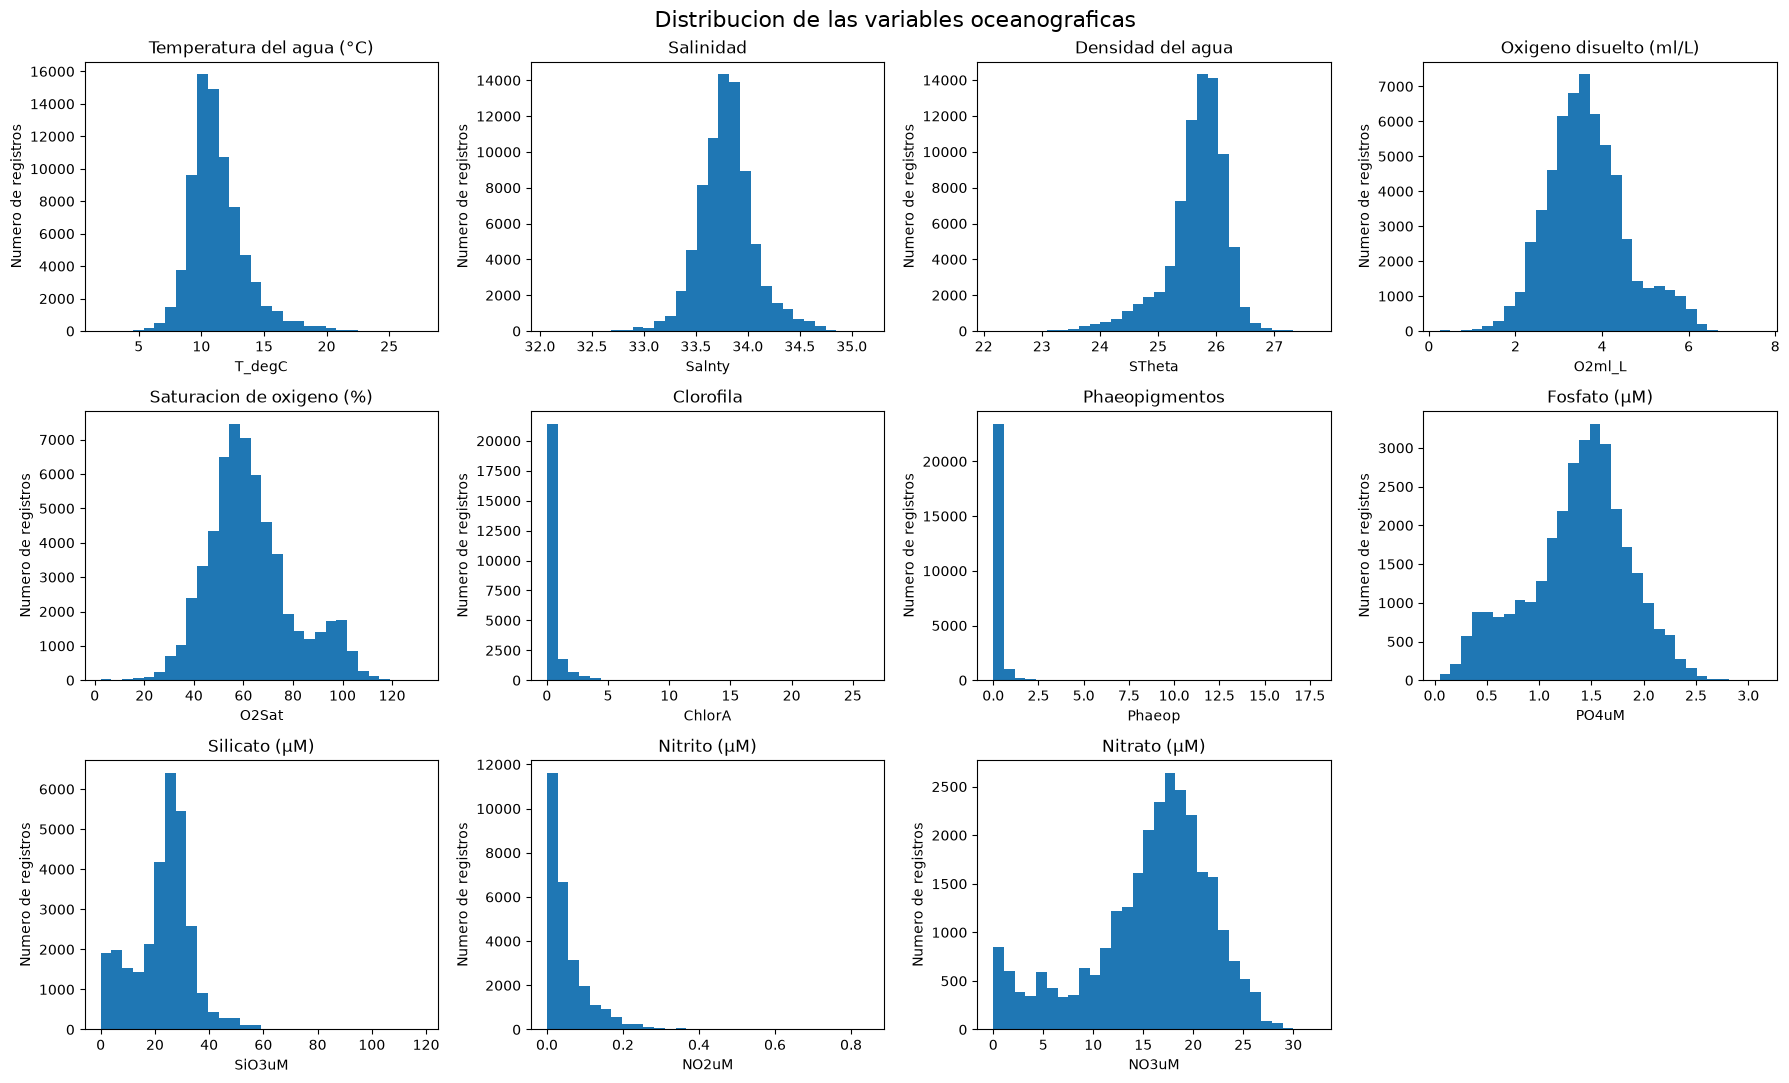

In [47]:
# Distribucion de las principales variables oceanograficas

import matplotlib.pyplot as plt

variables_oceanograficas = {
    "T_degC": "Temperatura del agua (°C)",
    "Salnty": "Salinidad",
    "STheta": "Densidad del agua",
    "O2ml_L": "Oxigeno disuelto (ml/L)",
    "O2Sat": "Saturacion de oxigeno (%)",
    "ChlorA": "Clorofila",
    "Phaeop": "Phaeopigmentos",
    "PO4uM": "Fosfato (µM)",
    "SiO3uM": "Silicato (µM)",
    "NO2uM": "Nitrito (µM)",
    "NO3uM": "Nitrato (µM)"
}

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()

for i, (variable, nombre) in enumerate(variables_oceanograficas.items()):
    axes[i].hist(
        dataset_final[variable].dropna(),
        bins=30
    )
    axes[i].set_title(nombre)
    axes[i].set_xlabel(variable)
    axes[i].set_ylabel("Numero de registros")

for i in range(len(variables_oceanograficas), len(axes)):
    axes[i].axis("off")

plt.suptitle("Distribucion de las variables oceanograficas", fontsize=16)
plt.tight_layout()
plt.show()


### Que vemos en estas variables

Las variables oceanograficas no se comportan todas de la misma forma.

La temperatura, la salinidad y la densidad se concentran bastante alrededor de determinados valores.

El oxigeno presenta una distribucion mas amplia, por lo que encontramos muestreos con condiciones bastante diferentes.

La clorofila, los phaeopigmentos y el nitrito tienen muchos valores bajos y unos pocos valores bastante altos.

Los nutrientes como fosfato, silicato y nitrato tambien presentan diferentes rangos y distribuciones.

De momento no consideramos los valores extremos como errores, ya que pueden representar condiciones reales del oceano.

Estas diferencias son importantes porque posteriormente queremos comprobar si algunas de estas condiciones ayudan a explicar la presencia de `Engraulis mordax` y `Sardinops sagax`.

### Que especies tenemos?

Antes de hacer la criba miramos cuales son las especies con mas registros.

Este grafico nos sirve tambien para justificar la eleccion de `Engraulis mordax` y `Sardinops sagax`.


## Seleccion del caso de estudio

A partir de aqui centramos el proyecto en dos especies:

- `Engraulis mordax`
- `Sardinops sagax`

No borramos el dataset general. Creamos un nuevo dataframe solo para el caso de estudio.

Asi mantenemos todo el trabajo anterior y utilizamos las dos especies para el analisis especifico y el futuro modelo de clasificacion.


In [48]:
# Creamos el dataset especifico para anchoa y sardina

especies_objetivo = [
    "Engraulis mordax",
    "Sardinops sagax"
]

dataset_modelo = dataset_final[
    dataset_final["scientificName"].isin(especies_objetivo)
].copy()

print("Filas del caso de estudio:", dataset_modelo.shape[0])
print("Columnas:", dataset_modelo.shape[1])

dataset_modelo["scientificName"].value_counts()


Filas del caso de estudio: 11263
Columnas: 28


scientificName
Engraulis mordax    8936
Sardinops sagax     2327
Name: count, dtype: int64

### Primer punto importante

Las dos especies no tienen la misma cantidad de registros.

`Engraulis mordax` tiene bastante mas informacion que `Sardinops sagax`.

Esto no impide hacer el proyecto, pero cuando entrenemos el modelo no podremos valorar su calidad solamente con accuracy. Tendremos que comprobar tambien como predice cada una de las dos especies.


## EDA centrado en Engraulis mordax y Sardinops sagax

A partir de este punto trabajamos con `dataset_modelo`.

La pregunta ya es mucho mas concreta: queremos ver si las dos especies se diferencian por zona, tiempo y condiciones oceanograficas.


In [49]:
# Revisamos los nulos dentro del dataset de las dos especies

nulos_modelo = pd.DataFrame({
    "nulos": dataset_modelo.isnull().sum(),
    "porcentaje_nulos": (dataset_modelo.isnull().mean() * 100).round(2)
})

nulos_modelo.sort_values(
    "porcentaje_nulos",
    ascending=False
)


,nulos,porcentaje_nulos
Wave_Ht,7681,68.20
IntChl,7191,63.85
ChlorA,6932,61.55
Phaeop,6932,61.55
NO2uM,6600,58.60
NO3uM,6594,58.55
SiO3uM,6388,56.72
PO4uM,6171,54.79
Wet_T,4871,43.25
Barometer,4847,43.03


### Comparacion sencilla de condiciones

Antes de llenar el notebook de graficos hacemos una tabla sencilla con valores tipicos de algunas variables importantes.

Usamos la mediana porque algunas variables tienen valores extremos y asi la comparacion es mas estable.


In [50]:
# Comparamos valores habituales de algunas variables importantes

variables_comparacion = [
    "T_degC",
    "Salnty",
    "O2ml_L",
    "Bottom_D",
    "Distance"
]

dataset_modelo.groupby(
    "scientificName"
)[variables_comparacion].median().round(2)


,T_degC,Salnty,O2ml_L,Bottom_D,Distance
scientificName,,,,,
Engraulis mordax,11.01,33.81,3.55,777.5,-30.94
Sardinops sagax,11.47,33.77,3.72,691.5,-37.63


### Donde aparecen las dos especies?

Ahora si usamos latitud y longitud juntas.

Queremos ver si `Engraulis mordax` y `Sardinops sagax` ocupan zonas parecidas o si su distribucion geografica presenta diferencias.


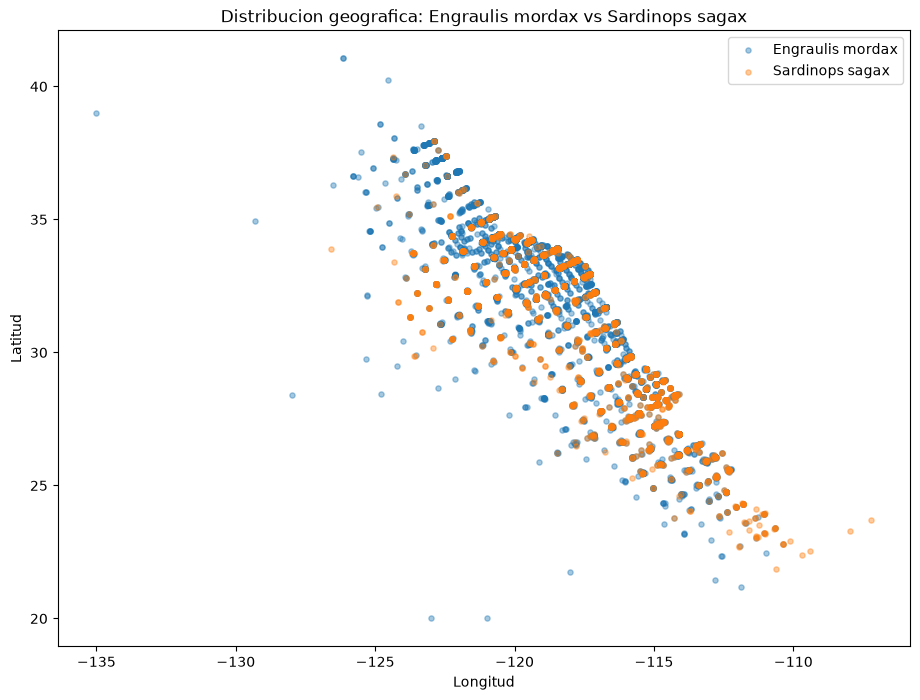

In [51]:
# Distribucion geografica de las dos especies

plt.figure(figsize=(11, 8))

for especie in especies_objetivo:

    datos_especie = dataset_modelo[
        dataset_modelo["scientificName"] == especie
    ]

    plt.scatter(
        datos_especie["Lon_Dec"],
        datos_especie["Lat_Dec"],
        s=14,
        alpha=0.4,
        label=especie
    )

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Distribucion geografica: Engraulis mordax vs Sardinops sagax")

plt.legend()
plt.show()


### Temperatura y salinidad

Ahora comprobamos si las dos especies aparecen bajo combinaciones diferentes de temperatura y salinidad.

Si se separan claramente, estas variables podrian ser muy utiles para el modelo. Si aparecen mezcladas, necesitaremos combinarlas con el resto de informacion.


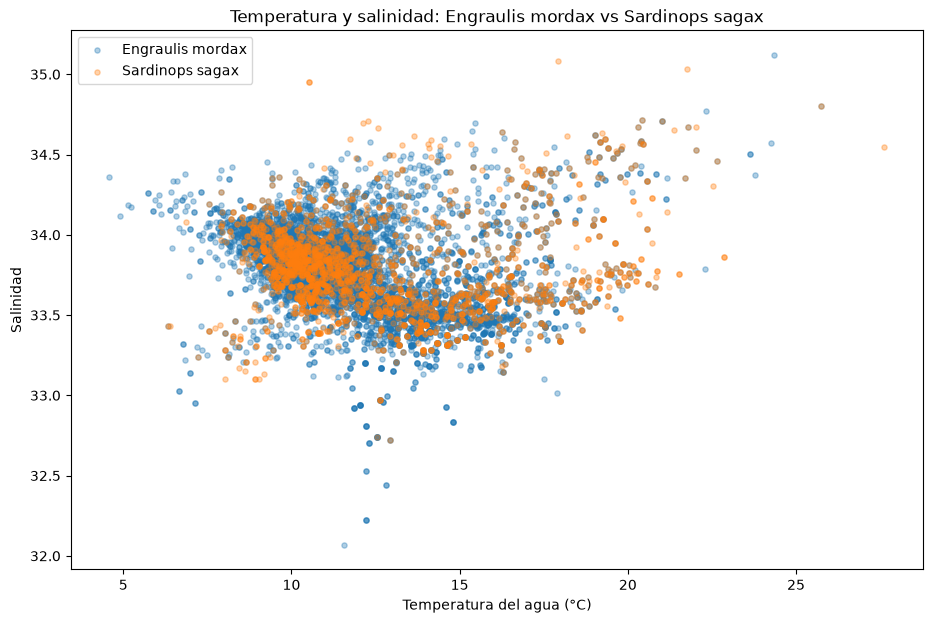

In [52]:
# Temperatura y salinidad para las dos especies

datos_oceano = dataset_modelo.dropna(
    subset=["T_degC", "Salnty"]
)

plt.figure(figsize=(11, 7))

for especie in especies_objetivo:

    datos_especie = datos_oceano[
        datos_oceano["scientificName"] == especie
    ]

    plt.scatter(
        datos_especie["T_degC"],
        datos_especie["Salnty"],
        s=14,
        alpha=0.35,
        label=especie
    )

plt.xlabel("Temperatura del agua (°C)")
plt.ylabel("Salinidad")
plt.title("Temperatura y salinidad: Engraulis mordax vs Sardinops sagax")

plt.legend()
plt.show()


### Como cambia la presencia relativa con los años?

No queremos confundir cantidad de muestreos con cantidad real de peces.

Por eso calculamos, dentro de los registros de estas dos especies, que porcentaje corresponde a cada una en cada año.

Para evitar conclusiones raras por años con poquisimos datos, mostramos solamente años con al menos 30 registros entre las dos especies.


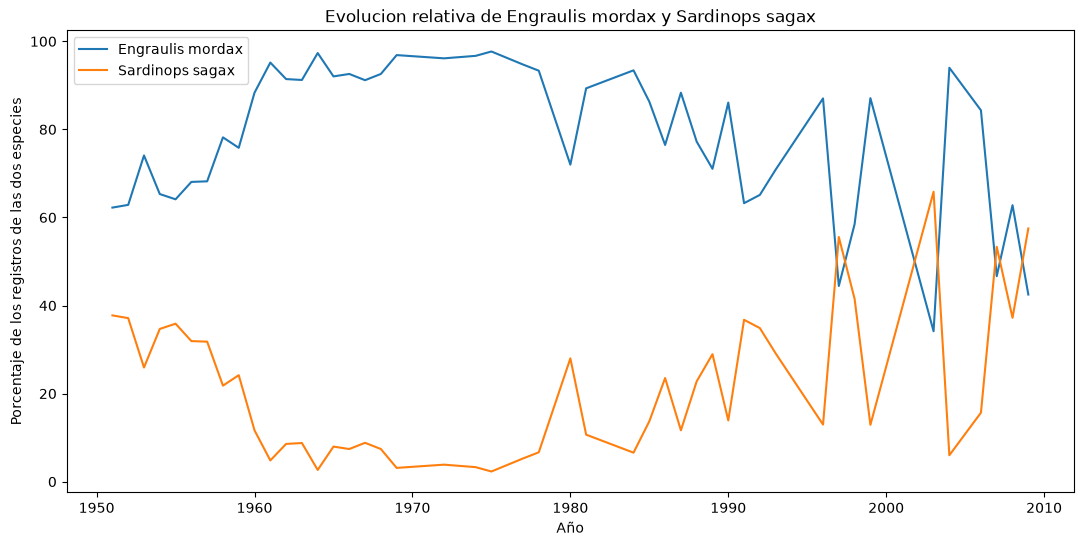

In [53]:
# Comparamos el peso relativo de las dos especies por año

conteo_anual = (
    dataset_modelo
    .groupby(["Year", "scientificName"])
    .size()
    .reset_index(name="registros")
)

total_anual = (
    dataset_modelo
    .groupby("Year")
    .size()
    .reset_index(name="total")
)

evolucion = conteo_anual.merge(
    total_anual,
    on="Year"
)

evolucion = evolucion[
    evolucion["total"] >= 30
].copy()

evolucion["porcentaje"] = (
    evolucion["registros"]
    / evolucion["total"]
    * 100
)

plt.figure(figsize=(13, 6))

for especie in especies_objetivo:

    datos_especie = evolucion[
        evolucion["scientificName"] == especie
    ]

    plt.plot(
        datos_especie["Year"],
        datos_especie["porcentaje"],
        label=especie
    )

plt.xlabel("Año")
plt.ylabel("Porcentaje de los registros de las dos especies")
plt.title("Evolucion relativa de Engraulis mordax y Sardinops sagax")

plt.legend()
plt.show()


### Relacion entre las variables oceanograficas

Por ultimo comprobamos si algunas variables numericas estan contando practicamente lo mismo.

Esto sera importante antes de preparar el Machine Learning.


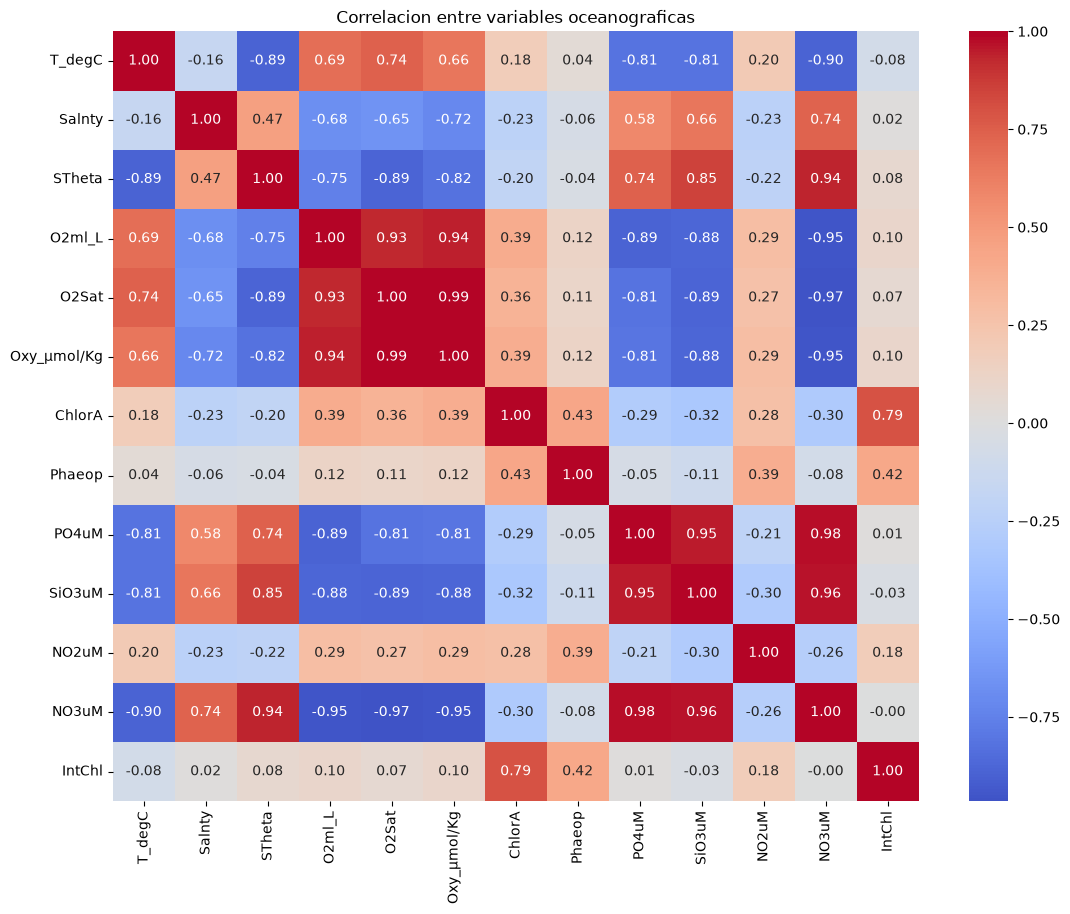

In [54]:
# Correlacion entre las principales variables oceanograficas
# dentro del caso de estudio

import seaborn as sns

variables_correlacion = [
    "T_degC",
    "Salnty",
    "STheta",
    "O2ml_L",
    "O2Sat",
    "Oxy_µmol/Kg",
    "ChlorA",
    "Phaeop",
    "PO4uM",
    "SiO3uM",
    "NO2uM",
    "NO3uM",
    "IntChl"
]

correlaciones = dataset_modelo[
    variables_correlacion
].corr()

plt.figure(figsize=(13, 10))

sns.heatmap(
    correlaciones,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlacion entre variables oceanograficas")
plt.show()


## Cierre del EDA

Despues de revisar los datos generales y centrar el estudio en `Engraulis mordax` y `Sardinops sagax`, ya tenemos una idea bastante clara de como esta construido nuestro problema.

No encontramos registros duplicados, aunque algunas variables tienen bastantes valores nulos, sobre todo las relacionadas con clorofila, nutrientes y algunas condiciones atmosfericas.

Tambien vimos que las dos especies no tienen la misma cantidad de datos. Tenemos bastante mas registros de `Engraulis mordax` que de `Sardinops sagax`, por lo que tendremos que tenerlo en cuenta cuando evaluemos el modelo.

La distribucion geografica de los datos tampoco es uniforme. Hay zonas mucho mas muestreadas que otras, por lo que no podemos interpretar directamente un mayor numero de registros como una mayor cantidad real de peces.

Algo parecido ocurre con los años. Algunos periodos tienen muchos mas muestreos que otros, asi que tendremos cuidado al interpretar los cambios temporales.

Al comparar temperatura y salinidad vemos que las dos especies comparten bastantes condiciones oceanograficas. Esto indica que probablemente no podamos diferenciarlas utilizando una sola variable y necesitaremos combinar distintas caracteristicas.

Con este EDA damos por terminada la fase de exploracion.

El siguiente paso sera preparar los datos para Machine Learning, construir correctamente la presencia o ausencia de cada especie en los muestreos y unir esa informacion con las condiciones oceanograficas.

A partir de ahi podremos entrenar modelos capaces de estimar la probabilidad de encontrar `Engraulis mordax` y `Sardinops sagax` en una zona y periodo determinados.

## Preparacion para Machine Learning

Ahora empezamos la parte de Machine Learning.

Queremos saber si las condiciones del oceano, la zona y el momento del muestreo nos ayudan a estimar donde es mas probable encontrar:

- `Engraulis mordax`
- `Sardinops sagax`




### Preparamos los datos para Machine Learning

Volvemos a `dataset_completo` para crear una tabla por muestreo y marcar si en cada uno aparece `Engraulis mordax` o `Sardinops sagax`.

Asi podremos trabajar despues con presencia `1` o no registro `0`.

In [55]:
# Creamos una copia para preparar los datos de Machine Learning

datos_ml = dataset_completo.copy()

# Marcamos la presencia de Engraulis mordax

datos_ml["presencia_engraulis"] = (
    datos_ml["scientificName"] == "Engraulis mordax"
)

# Marcamos la presencia de Sardinops sagax

datos_ml["presencia_sardinops"] = (
    datos_ml["scientificName"] == "Sardinops sagax"
)

datos_ml[
    [
        "eventID",
        "scientificName",
        "presencia_engraulis",
        "presencia_sardinops"
    ]
].head(10)

,eventID,scientificName,presencia_engraulis,presencia_sardinops
0,558933f2-02eb-ef11-a09e-2cea7fa0979c,Sardinops sagax,False,True
1,558933f2-02eb-ef11-a09e-2cea7fa0979c,Sardinops sagax,False,True
2,558933f2-02eb-ef11-a09e-2cea7fa0979c,Sardinops sagax,False,True
3,558933f2-02eb-ef11-a09e-2cea7fa0979c,Sardinops sagax,False,True
4,558933f2-02eb-ef11-a09e-2cea7fa0979c,Sardinops sagax,False,True
5,558933f2-02eb-ef11-a09e-2cea7fa0979c,Sardinops sagax,False,True
6,558933f2-02eb-ef11-a09e-2cea7fa0979c,Sardinops sagax,False,True
7,558933f2-02eb-ef11-a09e-2cea7fa0979c,Sardinops sagax,False,True
8,558933f2-02eb-ef11-a09e-2cea7fa0979c,Sardinops sagax,False,True
9,558933f2-02eb-ef11-a09e-2cea7fa0979c,Sardinops sagax,False,True


In [56]:
# Creamos una fila por cada muestreo

dataset_ml = (
    datos_ml
    .groupby("eventID")
    .agg({
        "Year": "first",
        "Month": "first",
        "Lat_Dec": "first",
        "Lon_Dec": "first",
        "T_degC": "mean",
        "Salnty": "mean",
        "STheta": "mean",
        "O2ml_L": "mean",
        "O2Sat": "mean",
        "Depthm": "mean",
        "Bottom_D": "first",
        "Distance": "first",
        "ChlorA": "mean",
        "Phaeop": "mean",
        "PO4uM": "mean",
        "SiO3uM": "mean",
        "NO2uM": "mean",
        "NO3uM": "mean",
        "IntChl": "first",
        "Wind_Spd": "first",
        "Wave_Ht": "first",
        "presencia_engraulis": "max",
        "presencia_sardinops": "max"
    })
    .reset_index()
)

dataset_ml.head()

,eventID,Year,Month,Lat_Dec,Lon_Dec,T_degC,Salnty,STheta,O2ml_L,O2Sat,...,Phaeop,PO4uM,SiO3uM,NO2uM,NO3uM,IntChl,Wind_Spd,Wave_Ht,presencia_engraulis,presencia_sardinops
0,001b3af2-02eb-ef11-a09e-2cea7fa0979c,2010,8,34.258333,-119.323333,13.956667,33.579500,25.077400,5.262000,90.040000,...,1.416,0.606,7.04,0.216,4.08,120.7,4.0,NaN,False,False
1,002547f2-02eb-ef11-a09e-2cea7fa0979c,1958,10,34.441666,-120.541666,15.751111,33.395556,24.555667,5.436667,96.244444,...,NaN,NaN,NaN,NaN,NaN,NaN,18.0,NaN,True,False
2,002947f2-02eb-ef11-a09e-2cea7fa0979c,1959,5,37.641666,-123.483333,9.046207,33.759276,26.131103,3.625172,56.558621,...,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,True,False
3,002b47f2-02eb-ef11-a09e-2cea7fa0979c,1959,8,30.483333,-117.775000,12.137742,33.781161,25.514774,3.593226,61.703226,...,NaN,NaN,NaN,NaN,NaN,NaN,13.0,NaN,False,False
4,002d47f2-02eb-ef11-a09e-2cea7fa0979c,1959,10,28.933333,-114.691666,17.903333,33.761444,24.325889,4.952222,91.722222,...,NaN,NaN,NaN,NaN,NaN,NaN,24.0,NaN,True,False


In [57]:
dataset_ml.info()


<class 'pandas.DataFrame'>
RangeIndex: 14105 entries, 0 to 14104
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   eventID              14105 non-null  str    
 1   Year                 14105 non-null  int64  
 2   Month                14105 non-null  int64  
 3   Lat_Dec              14105 non-null  float64
 4   Lon_Dec              14105 non-null  float64
 5   T_degC               14086 non-null  float64
 6   Salnty               13935 non-null  float64
 7   STheta               13928 non-null  float64
 8   O2ml_L               10908 non-null  float64
 9   O2Sat                10772 non-null  float64
 10  Depthm               14105 non-null  float64
 11  Bottom_D             13429 non-null  float64
 12  Distance             7955 non-null   float64
 13  ChlorA               4941 non-null   float64
 14  Phaeop               4941 non-null   float64
 15  PO4uM                6021 non-null   float64
 1

In [58]:
nulos = pd.DataFrame({
    "Cantidad": dataset_ml.isnull().sum(),
    "Porcentaje": (dataset_ml.isnull().sum() / len(dataset_ml) * 100).round(2)
})

nulos.sort_values("Porcentaje", ascending=False)

,Cantidad,Porcentaje
Wave_Ht,9573,67.87
IntChl,9334,66.18
ChlorA,9164,64.97
Phaeop,9164,64.97
NO2uM,8969,63.59
NO3uM,8804,62.42
SiO3uM,8482,60.13
PO4uM,8084,57.31
Distance,6150,43.60
O2Sat,3333,23.63





Al revisar el dataset encontramos varias variables con una cantidad muy alta de datos faltantes.

Para evitar tener que rellenar una parte demasiado grande de la información, decidimos eliminar las variables con más valores nulos y trabajar con las que tienen una mayor cantidad de datos reales.

También eliminamos `Distance`, ya que tiene muchos valores faltantes y la localización ya está representada por `Lat_Dec` y `Lon_Dec`.

Las variables con una cantidad menor de nulos se mantendrán y las trataremos antes de entrenar los modelos.

In [59]:
dataset_ml = dataset_ml.drop(columns=[
    "Wave_Ht",
    "IntChl",
    "ChlorA",
    "Phaeop",
    "NO2uM",
    "NO3uM",
    "SiO3uM",
    "PO4uM",
    "Distance"
])

dataset_ml.info()

<class 'pandas.DataFrame'>
RangeIndex: 14105 entries, 0 to 14104
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   eventID              14105 non-null  str    
 1   Year                 14105 non-null  int64  
 2   Month                14105 non-null  int64  
 3   Lat_Dec              14105 non-null  float64
 4   Lon_Dec              14105 non-null  float64
 5   T_degC               14086 non-null  float64
 6   Salnty               13935 non-null  float64
 7   STheta               13928 non-null  float64
 8   O2ml_L               10908 non-null  float64
 9   O2Sat                10772 non-null  float64
 10  Depthm               14105 non-null  float64
 11  Bottom_D             13429 non-null  float64
 12  Wind_Spd             13321 non-null  float64
 13  presencia_engraulis  14105 non-null  bool   
 14  presencia_sardinops  14105 non-null  bool   
dtypes: bool(2), float64(10), int64(2), str(1)
memor

In [60]:
dataset_ml["presencia_engraulis"].value_counts()

presencia_engraulis
False    7690
True     6415
Name: count, dtype: int64

In [61]:
dataset_ml["presencia_sardinops"].value_counts()

presencia_sardinops
False    12346
True      1759
Name: count, dtype: int64

### tenemos un desbalance enorme en la presencia de sardinas lo que debe tenernos atento en el modelo despues .... puedes ser que aciert mucho pero por que existe este desbalanceo


In [62]:
# Variables que todavía tienen algunos valores nulos
columnas_nulos = [
    "T_degC",
    "Salnty",
    "STheta",
    "O2ml_L",
    "O2Sat",
    "Bottom_D",
    "Wind_Spd"
]

# Rellenamos los nulos con la mediana de cada variable
for columna in columnas_nulos:
    dataset_ml[columna] = dataset_ml[columna].fillna(
        dataset_ml[columna].median()
    )

In [63]:
# Comprobamos que ya no quedan valores nulos

dataset_ml.isnull().sum()

eventID                0
Year                   0
Month                  0
Lat_Dec                0
Lon_Dec                0
T_degC                 0
Salnty                 0
STheta                 0
O2ml_L                 0
O2Sat                  0
Depthm                 0
Bottom_D               0
Wind_Spd               0
presencia_engraulis    0
presencia_sardinops    0
dtype: int64

In [64]:
# Variables que usará el modelo para aprender
X = dataset_ml.drop(columns=[
    "eventID",
    "presencia_engraulis",
    "presencia_sardinops"
])

# Objetivo para Engraulis mordax
y_engraulis = dataset_ml["presencia_engraulis"]

# Objetivo para Sardinops sagax
y_sardinops = dataset_ml["presencia_sardinops"]

In [65]:
# Revisamos que todo tenga el mismo número de filas

print("X:", X.shape)
print("Engraulis:", y_engraulis.shape)
print("Sardinops:", y_sardinops.shape)

X: (14105, 12)
Engraulis: (14105,)
Sardinops: (14105,)


In [66]:
# Guardamos el dataset definitivo para Machine Learning

dataset_ml.to_csv(
    "../../data/processed/dataset_ml.csv",
    index=False
)